# Fast convolution

So, the english is not very good, I will improve that

In [1]:
import itertools

import sympy as sy
import numpy as np

In [2]:
import fitz

In [3]:
from utils import plot_pdf

In [4]:
doc = fitz.open('tolimieri et al_2013_Algorithms for Discrete Fourier Transform and Convolution.pdf')

The base for this tutorial is the book "Fast Algorithms or Signal Processing" of Blahut.
Is an excellent book but full of examples but, of course, do not explain everything in details.
For that parts I will quote another books and videos from YouTube.

The book puts first all theory and only after that we have a detailed example. To better understanding in this tutorial we have quotes from theory and examples together fallowing the sequence of commands

This example will not work for different vector sizes.

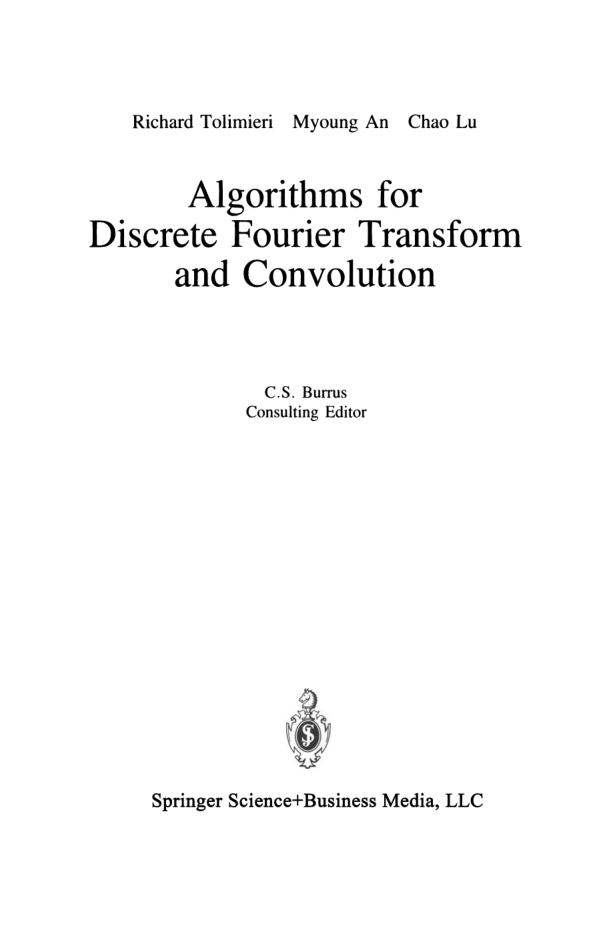

In [5]:
plot_pdf(doc[1], dpi=100)

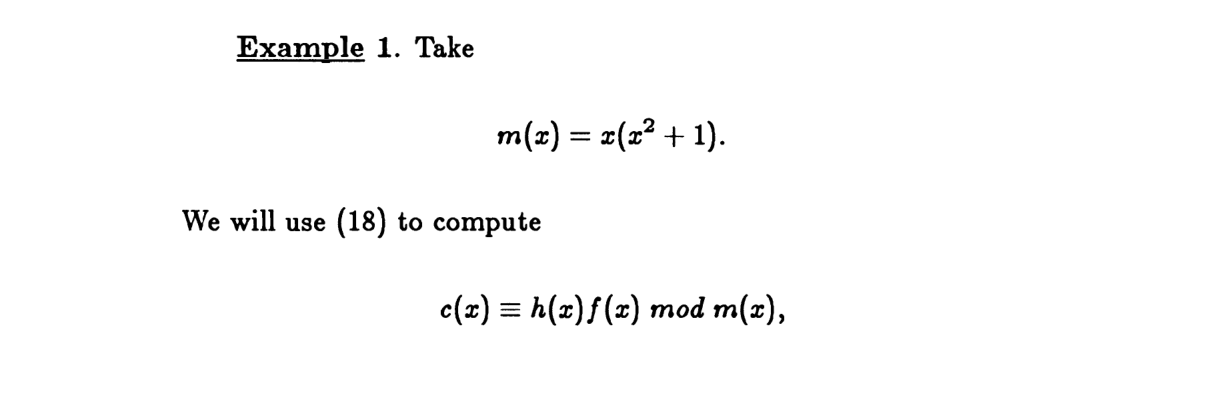

In [6]:
plot_pdf(doc[170], [.73, .95])

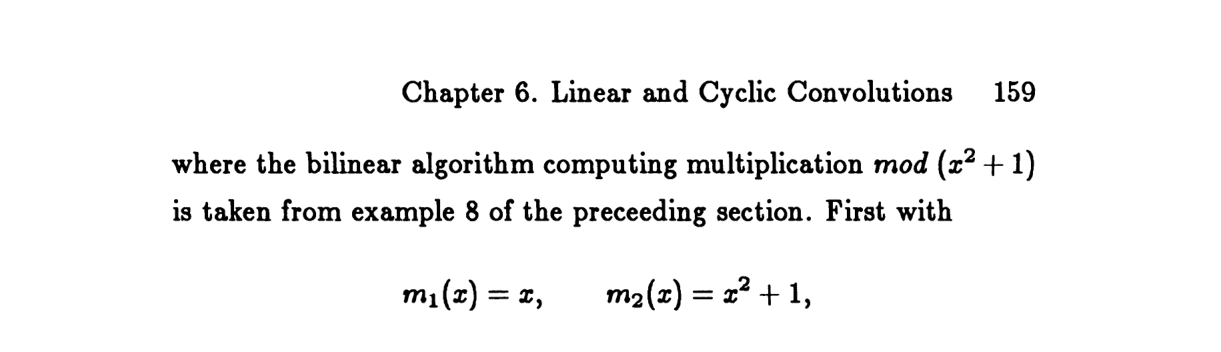

In [28]:
plot_pdf(doc[171], [0.05, .24])

## Start

Size of vectors

In [8]:
d_num = 3
g_num = 3

Example of vectors for the convolution

In [9]:
d_values = list(range(1, d_num+1))
g_values = list(range(1, g_num+1))
print(d_values, g_values)

[1, 2, 3] [1, 2, 3]


Polynomial degree

In [10]:
d_degree = d_num - 1
g_degree = g_num - 1
print(d_degree, g_degree)

2 2


In [11]:
x = sy.symbols("x")
x

x

In [12]:
di = sy.Matrix(sy.symbols(" ".join(f"d_{i}"for i in range(d_num))))
di

Matrix([
[d_0],
[d_1],
[d_2]])

In [13]:
gi = sy.Matrix(sy.symbols(" ".join(f"g_{i}"for i in range(g_num))))
gi

Matrix([
[g_0],
[g_1],
[g_2]])

In [14]:
dx = sum([i*x**e for e, i in enumerate(di)])
dx

d_0 + d_1*x + d_2*x**2

In [15]:
gx = sum([i*x**e for e, i in enumerate(gi)])
gx

g_0 + g_1*x + g_2*x**2

In [16]:
sx = gx*dx
sx

(d_0 + d_1*x + d_2*x**2)*(g_0 + g_1*x + g_2*x**2)

In [18]:
mk = sy.Matrix([x, x**2+1])
mk

Matrix([
[       x],
[x**2 + 1]])

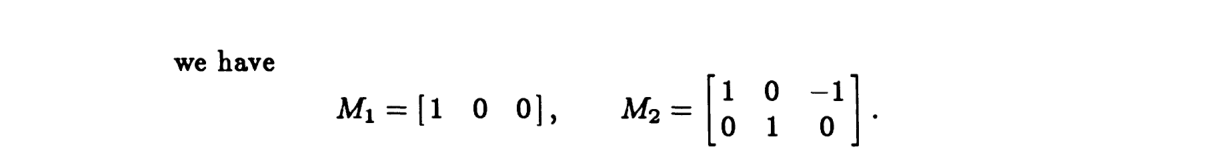

In [ ]:
plot_pdf(doc[171], [0.22, 0.31])

In [55]:
dk = sy.Matrix([sy.rem(dx, q, domain ='ZZ') for q in mk])
dk

Matrix([
[              d_0],
[d_0 + d_1*x - d_2]])

In [78]:
a0_lst = [[d.coeff(c, 1) for c in di] for d in dk[:-1]]
sy.Matrix(a0_lst)

Matrix([[1, 0, 0]])

In [57]:
a20_lst = sy.Matrix([dk[-1].subs({x:0}).coeff(c, 1) for c in di])
a20_lst

[1, 0, -1]

In [58]:
a21_lst = [sy.div(dk[-1], c, domain ='QQ')[0].subs({x:1}) for c in di]
a21_lst

[0, 1, 0]

In [79]:
sy.Matrix([a20_lst, a21_lst])

Matrix([
[1, 0, -1],
[0, 1,  0]])

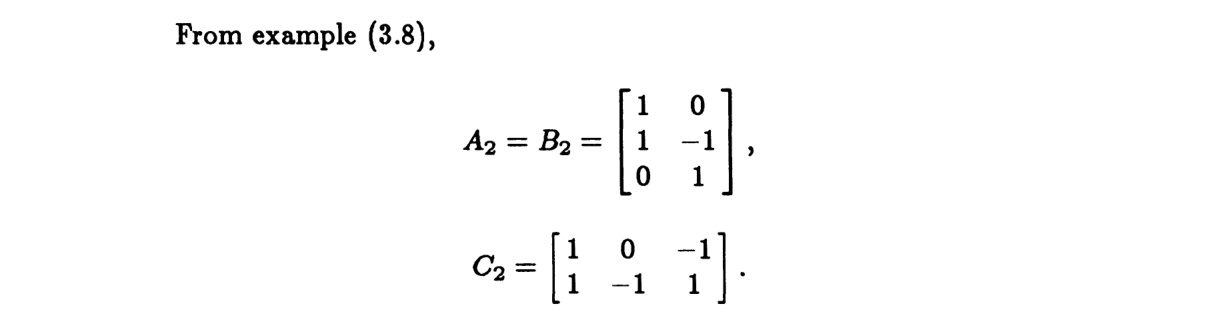

In [48]:
plot_pdf(doc[171], [0.30, 0.47])

In [64]:
a2_mtx = sy.Matrix([[1, 0], [1, -1], [0, 1]])
a2_mtx

Matrix([
[1,  0],
[1, -1],
[0,  1]])

In [38]:
b2_mtx = a2_mtx
b2_mtx

Matrix([
[1,  0],
[1, -1],
[0,  1]])

In [82]:
c2_mtx = sy.Matrix([
    [1, 0, -1],
    [1, -1, 1],
])
c2_mtx

Matrix([
[1,  0, -1],
[1, -1,  1]])

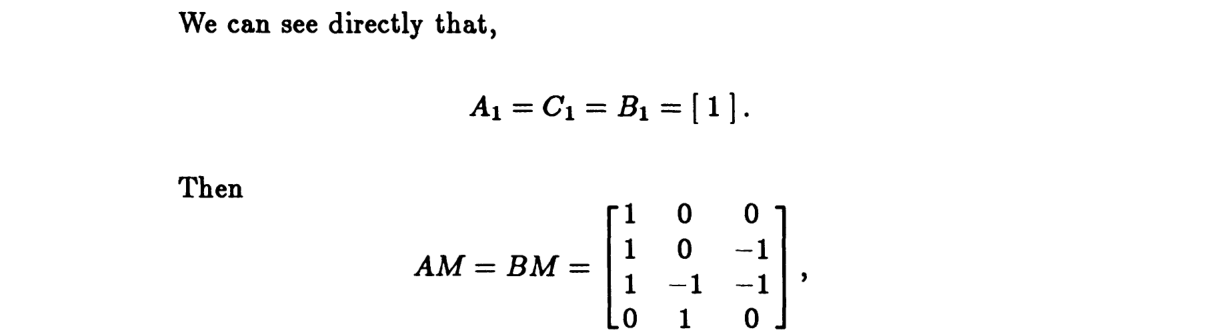

In [106]:
plot_pdf(doc[171], [0.47, 0.65])

In [59]:
a0_mtx = sy.Matrix(np.vstack([a0_lst, a20_lst, a21_lst]))
a0_mtx

Matrix([
[1, 0,  0],
[1, 0, -1],
[0, 1,  0]])

In [65]:
a2e_mtx = sy.Matrix(sy.diag(sy.eye(1), a2_mtx))
a2e_mtx

Matrix([
[1, 0,  0],
[0, 1,  0],
[0, 1, -1],
[0, 0,  1]])

In [66]:
a_mtx = a2e_mtx * a0_mtx
a_mtx

Matrix([
[1,  0,  0],
[1,  0, -1],
[1, -1, -1],
[0,  1,  0]])

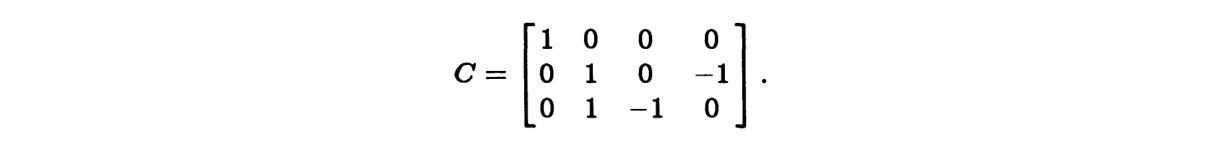

In [117]:
plot_pdf(doc[171], [0.65, 0.73])

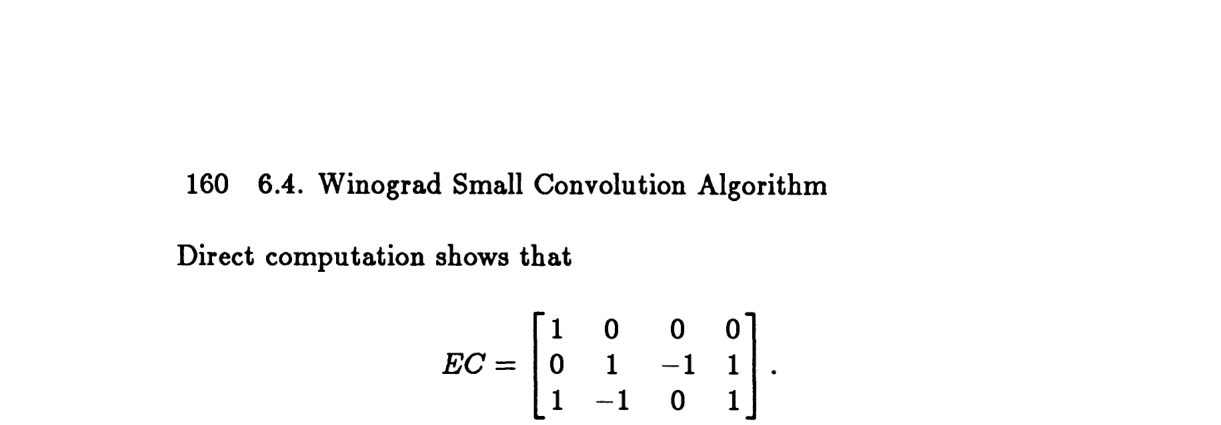

In [116]:
plot_pdf(doc[172], [0, 0.23])

In [91]:
mmk = sy.Matrix([sy.expand(np.prod(d)) for d in itertools.combinations(reversed(mk), len(mk)-1)])
mmk

Matrix([
[x**2 + 1],
[       x]])

In [135]:
e1 = mk[1]
e1

x**2 + 1

In [136]:
e2 = (mk[1] - 1)* -1
e2

-x**2

In [122]:
sy.div(mk[1]*mk[0], mk[0], domain ='ZZ')

(x**2 + 1, 0)

In [131]:
sy.div(-x**2, mk[1], domain ='ZZ')

(-1, 1)

In [69]:
mmk_div = [sy.div(dv, ds, domain ='ZZ') for dv, ds in zip(mmk, mk)]

In [70]:
mmk_quo = sy.Matrix([x[0] for x in mmk_div])
mmk_quo

Matrix([
[x],
[0]])

In [71]:
mmk_rem = sy.Matrix([x[1] for x in mmk_div])
mmk_rem

Matrix([
[1],
[x]])

In [72]:
nnk = sy.Matrix([1/z for z in mmk_rem])
nnk

Matrix([
[  1],
[1/x]])

In [76]:
c0_mtx = sy.Matrix([[d.coeff(x, c) for d in mmk] for c in range(len(np.prod(mk).as_poly().all_coeffs())-1)])
c0_mtx

Matrix([
[1, 0],
[0, 1],
[1, 0]])

In [98]:
c20_mtx = sy.expand(mmk[1])
c20_mtx

x

In [99]:
# c21_mtx = sy.rem(np.prod(mk), sy.expand(c20_mtx*x), domain ='ZZ')
c21_mtx = (c20_mtx*x).expand()
c21_mtx

x**2

In [100]:
mmk_new = sy.Matrix(mmk[:-1] + [c20_mtx] + [c21_mtx])
mmk_new

Matrix([
[x**2 + 1],
[       x],
[    x**2]])

In [101]:
c0_mtx = sy.Matrix([[d.coeff(x, c) for d in mmk_new] for c in range(len(np.prod(mk).as_poly().all_coeffs())-1)])
c0_mtx

Matrix([
[1, 0, 0],
[0, 1, 0],
[1, 0, 1]])

In [102]:
c2e_mtx = sy.Matrix(sy.diag(sy.eye(1), c2_mtx))
c2e_mtx

Matrix([
[1, 0,  0,  0],
[0, 1,  0, -1],
[0, 1, -1,  1]])

In [104]:
c_mtx = c0_mtx*c2e_mtx
c_mtx

Matrix([
[1, 0,  0,  0],
[0, 1,  0, -1],
[1, 1, -1,  1]])

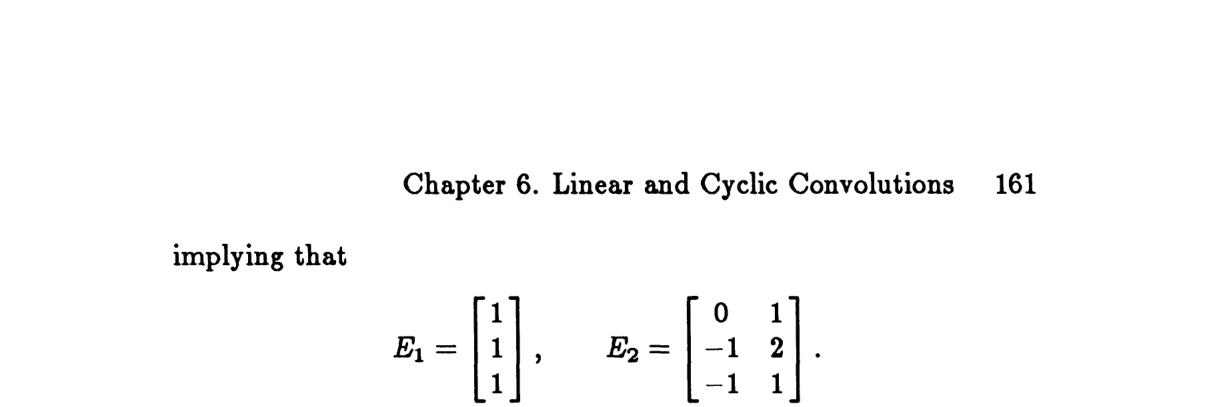

In [115]:
plot_pdf(doc[173], [0, .22])

In [20]:
gk = sy.Matrix([sy.rem(gx, q, domain ='ZZ') for q in mk])
gk

Matrix([
[              g_0],
[g_0 + g_1*x - g_2]])

In [21]:
dk = sy.Matrix([sy.rem(dx, q, domain ='ZZ') for q in mk])
dk

Matrix([
[              d_0],
[d_0 + d_1*x - d_2]])